In [2]:
import pandas as pd

# Load the data from the CSV file
df = pd.read_csv("../Data/Cleaned/Cleaned_Production_Data.csv")

# Display the first 5 rows of the DataFrame
display(df.head())

,Date,Start_Hour,End_Hour,Day_of_Year,Production,Temperature_C,Humidity_Percent,Precipitation_mm,WindSpeed_kmh,Source_Wind,...,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Rainfall_Flag_Yes
0,2025-11-30,21,22,334,5281,11.8,72,0.0,5.9,1,...,0,0,0,0,0,0,1,0,0,0
1,2025-11-30,18,19,334,3824,13.5,67,0.0,7.2,1,...,0,0,0,0,0,0,1,0,0,0
2,2025-11-30,16,17,334,3824,17.3,50,0.0,5.1,1,...,0,0,0,0,0,0,1,0,0,0
3,2025-11-30,23,0,334,6120,10.4,69,0.0,5.4,1,...,0,0,0,0,0,0,1,0,0,0
4,2025-11-30,6,7,334,4387,8.2,62,0.0,1.6,1,...,0,0,0,0,0,0,1,0,0,0


In [3]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract month and year as new features
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

# Drop the original 'Date' column and 'Start_Hour', 'End_Hour'
df = df.drop(columns=['Date', 'Start_Hour', 'End_Hour'])

# Display the first 5 rows of the modified DataFrame
display(df.head())

,Day_of_Year,Production,Temperature_C,Humidity_Percent,Precipitation_mm,WindSpeed_kmh,Source_Wind,Season_Spring,Season_Summer,Season_Winter,...,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Rainfall_Flag_Yes,month,year
0,334,5281,11.8,72,0.0,5.9,1,0,0,0,...,0,0,0,0,1,0,0,0,11,2025
1,334,3824,13.5,67,0.0,7.2,1,0,0,0,...,0,0,0,0,1,0,0,0,11,2025
2,334,3824,17.3,50,0.0,5.1,1,0,0,0,...,0,0,0,0,1,0,0,0,11,2025
3,334,6120,10.4,69,0.0,5.4,1,0,0,0,...,0,0,0,0,1,0,0,0,11,2025
4,334,4387,8.2,62,0.0,1.6,1,0,0,0,...,0,0,0,0,1,0,0,0,11,2025


In [4]:
# Define target variable (y) and features (X)
y = df['Production']
X = df.drop('Production', axis=1)

# Display the shapes of X and y
print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (51862, 29)
Shape of y (target): (51862,)


In [5]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (41489, 29)
Shape of X_test: (10373, 29)
Shape of y_train: (41489,)
Shape of y_test: (10373,)


In [6]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier viewing and further processing (optional but good for inspection)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Display the first 5 rows of the scaled training features
print("Scaled X_train (first 5 rows):")
display(X_train_scaled.head())

Scaled X_train (first 5 rows):


,Day_of_Year,Temperature_C,Humidity_Percent,Precipitation_mm,WindSpeed_kmh,Source_Wind,Season_Spring,Season_Summer,Season_Winter,Day_Name_Monday,...,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Rainfall_Flag_Yes,month,year
0,0.918976,0.213090,-0.364966,-0.170859,-1.177845,0.469400,-0.583241,-0.58454,-0.557556,-0.407404,...,-0.307071,-0.300444,-0.306083,-0.305611,-0.302252,3.243690,-0.302537,-0.354808,1.039328,0.907492
1,1.617977,-0.563468,-0.765946,-0.170859,-1.333536,0.469400,-0.583241,-0.58454,1.793541,-0.407404,...,-0.307071,-0.300444,-0.306083,-0.305611,-0.302252,-0.308291,-0.302537,-0.354808,1.624956,-0.274363
2,1.263689,-0.551141,0.637484,3.835664,1.261309,0.469400,-0.583241,-0.58454,-0.557556,-0.407404,...,-0.307071,-0.300444,-0.306083,-0.305611,3.308498,-0.308291,-0.302537,2.818426,1.332142,-0.274363
3,0.746620,0.878711,0.186382,-0.170859,-0.347495,-2.130379,-0.583241,-0.58454,-0.557556,-0.407404,...,-0.307071,-0.300444,-0.306083,-0.305611,-0.302252,-0.308291,3.305382,-0.354808,0.746514,-0.865290
4,1.685004,-1.561899,1.138709,-0.170859,-0.399392,0.469400,-0.583241,-0.58454,1.793541,-0.407404,...,-0.307071,-0.300444,-0.306083,-0.305611,-0.302252,-0.308291,-0.302537,-0.354808,1.624956,-1.456217


### Random Forest Regressor

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
print("Training Random Forest Regressor...")
rf_model.fit(X_train_scaled, y_train)
print("Random Forest Regressor training complete.")

# Make predictions on the scaled test data
rf_predictions = rf_model.predict(X_test_scaled)

# Calculate RMSE
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print(f"Random Forest Regressor RMSE: {rf_rmse:.2f}")

# Calculate MAE
rf_mae = mean_absolute_error(y_test, rf_predictions)
print(f"Random Forest Regressor MAE: {rf_mae:.2f}")

Training Random Forest Regressor...
Random Forest Regressor training complete.
Random Forest Regressor RMSE: 1655.81
Random Forest Regressor MAE: 1173.40


### XGBoost Regressor

In [8]:
import xgboost as xgb

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(random_state=42)

# Train the model
print("Training XGBoost Regressor...")
xgb_model.fit(X_train_scaled, y_train)
print("XGBoost Regressor training complete.")

# Make predictions on the scaled test data
xgb_predictions = xgb_model.predict(X_test_scaled)

# Calculate RMSE
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
print(f"XGBoost Regressor RMSE: {xgb_rmse:.2f}")

# Calculate MAE
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
print(f"XGBoost Regressor MAE: {xgb_mae:.2f}")

Training XGBoost Regressor...
XGBoost Regressor training complete.
XGBoost Regressor RMSE: 2232.95
XGBoost Regressor MAE: 1731.00


In [9]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate R2 for Random Forest
rf_r2 = r2_score(y_test, rf_predictions)
print(f"Random Forest Regressor R2: {rf_r2:.2f}")

# Calculate R2 for XGBoost
xgb_r2 = r2_score(y_test, xgb_predictions)
print(f"XGBoost Regressor R2: {xgb_r2:.2f}")

Random Forest Regressor R2: 0.83
XGBoost Regressor R2: 0.68


### Visualization: Random Forest Predictions vs. Actual Values

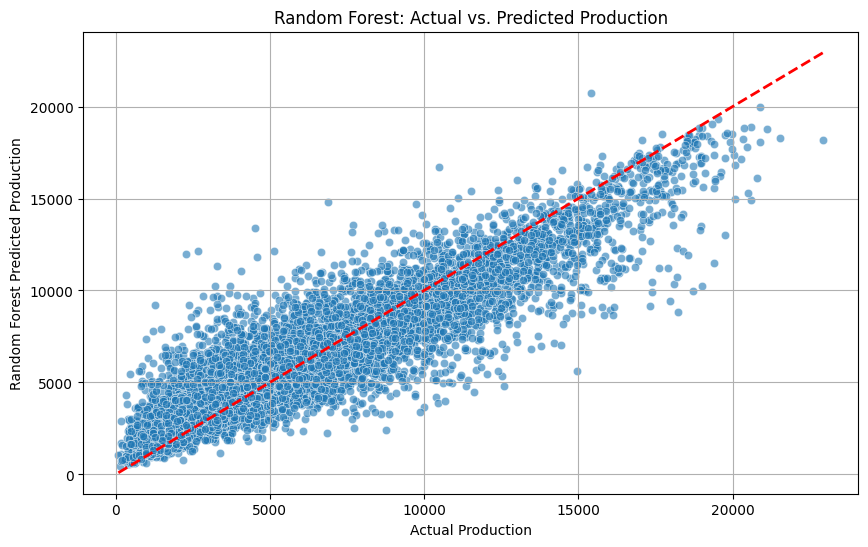

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=rf_predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Production')
plt.ylabel('Random Forest Predicted Production')
plt.title('Random Forest: Actual vs. Predicted Production')
plt.grid(True)
plt.show()

### Visualization: XGBoost Predictions vs. Actual Values

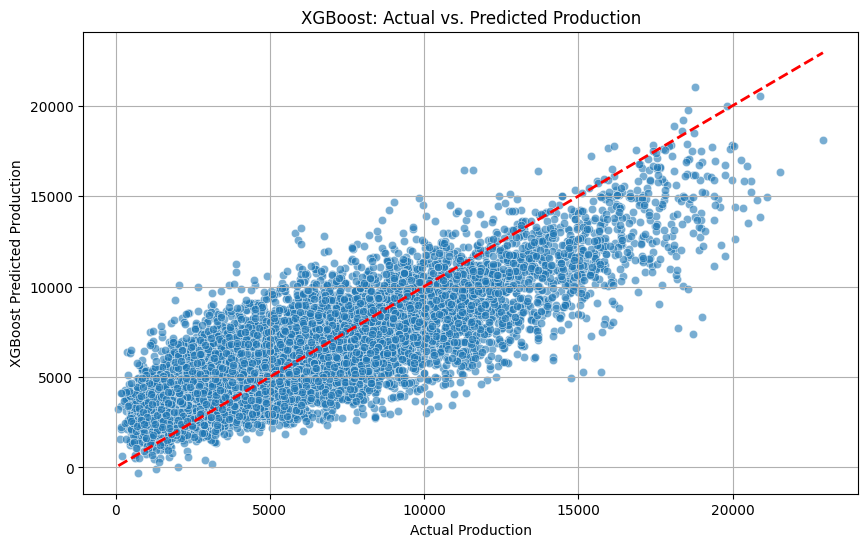

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=xgb_predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Production')
plt.ylabel('XGBoost Predicted Production')
plt.title('XGBoost: Actual vs. Predicted Production')
plt.grid(True)
plt.show()